## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
#! pip install ucimlrepo

In [2]:
import sys
import subprocess

subprocess.run([sys.executable, "-m", "pip", "install", "ucimlrepo"])

CompletedProcess(args=['C:\\Users\\Yvonne\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', '-m', 'pip', 'install', 'ucimlrepo'], returncode=0)

In [3]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None

--- Summary Statistics ---
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.94

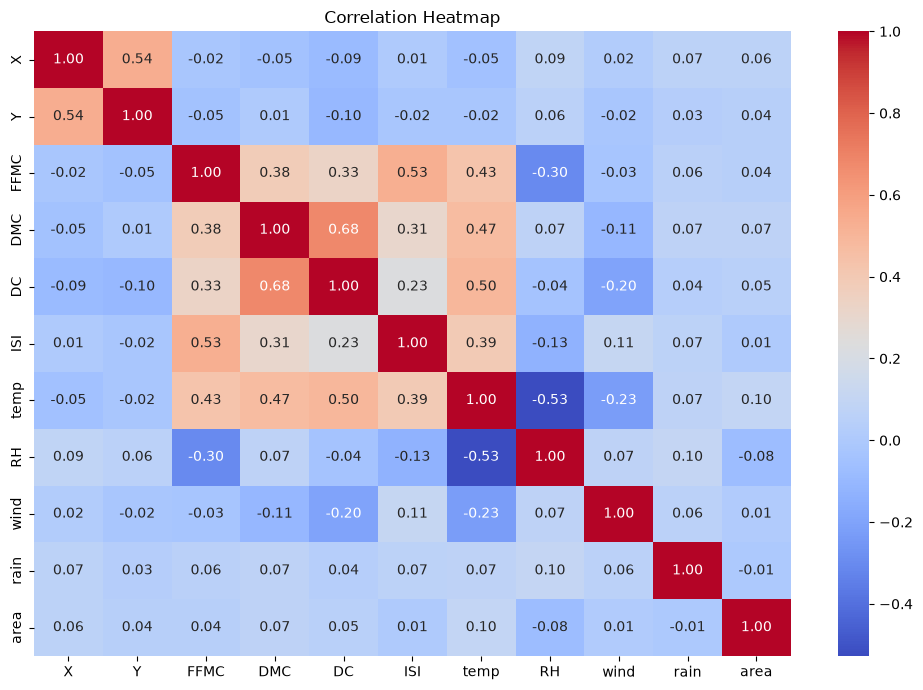

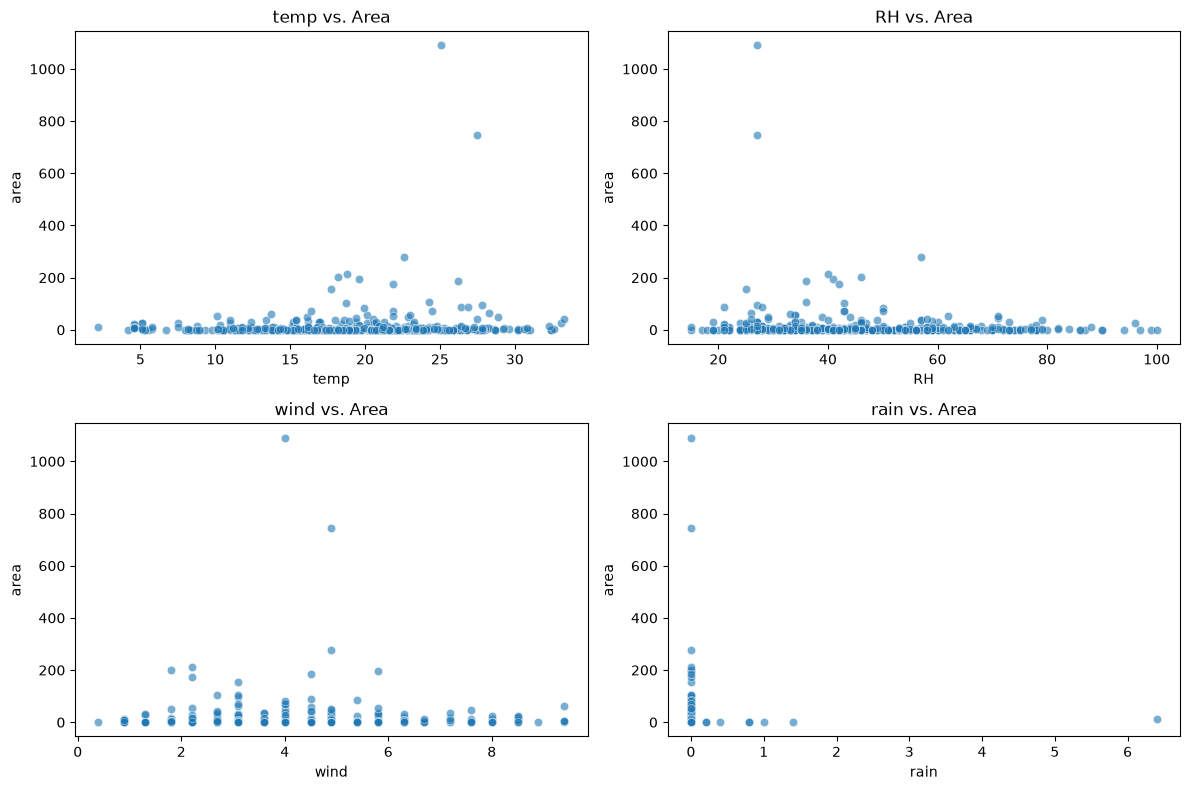

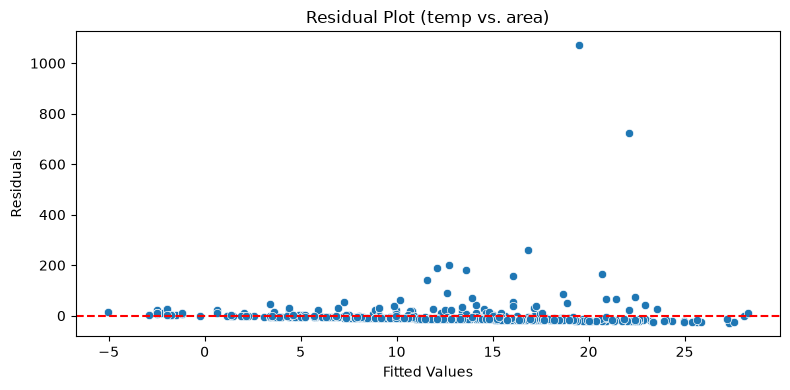

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Combine X and y into a single DataFrame
df = pd.concat([X, y], axis=1)

# Examine dataset structure and summary statistics
print("--- Dataset Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

# 2. Analyze correlations between numerical predictors and the target variable
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print("\n--- Correlation with Target ('area') ---")
print(corr_matrix['area'].sort_values(ascending=False))

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3. Plot scatterplots for key predictors vs target
key_predictors = ['temp', 'RH', 'wind', 'rain']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, ax in zip(key_predictors, axes.flatten()):
    sns.scatterplot(data=df, x=col, y='area', alpha=0.6, ax=ax)
    ax.set_title(f"{col} vs. Area")
plt.tight_layout()
plt.show()

# 4. Generate a residual plot to check for randomness in residuals
lr = LinearRegression()
X_eda = df[['temp']]
y_eda = df['area']
lr.fit(X_eda, y_eda)
predictions = lr.predict(X_eda)
residuals = y_eda - predictions

plt.figure(figsize=(8, 4))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (temp vs. area)")
plt.tight_layout()
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [5]:
import statsmodels.api as sm

# Prepare dataset for regression
df_reg = df.copy()

# 1. Apply logarithmic transformation to skewed target 'area' (and predictors if needed)
df_reg['log_area'] = np.log1p(df_reg['area'])

# 2. Incorporate indicator (dummy) variables for categorical variables ('month', 'day')
df_reg = pd.get_dummies(df_reg, columns=['month', 'day'], drop_first=True, dtype=float)

# 3. Fit baseline multiple linear regression model with key weather predictors
baseline_cols = ['temp', 'RH', 'wind', 'rain']
X_base = sm.add_constant(df_reg[baseline_cols])
model_base = sm.OLS(df_reg['log_area'], X_base).fit()
print("=== BASELINE MODEL SUMMARY ===")
print(model_base.summary())

# 4. Include nonlinear terms (e.g. quadratic) and interaction terms
df_reg['temp_squared'] = df_reg['temp'] ** 2
df_reg['temp_x_wind'] = df_reg['temp'] * df_reg['wind']

# 5. Fit extended model with all engineered predictors
predictors_ext = [col for col in df_reg.columns if col not in ['area', 'log_area']]
X_ext = sm.add_constant(df_reg[predictors_ext])
model_ext = sm.OLS(df_reg['log_area'], X_ext).fit()
print("\n=== EXTENDED MODEL SUMMARY ===")
print(model_ext.summary())

=== BASELINE MODEL SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.345
Date:                Tue, 22 Sep 2026   Prob (F-statistic):              0.252
Time:                        14:41:30   Log-Likelihood:                -903.77
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     512   BIC:                             1839.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7420

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

--- Model Comparison ---
        Metric  Baseline Model  Extended Model
     R-squared        0.010402        0.081057
Adj. R-squared        0.002671        0.026335
           AIC     1817.532067     1829.235421
           BIC     1838.772282     1956.676707


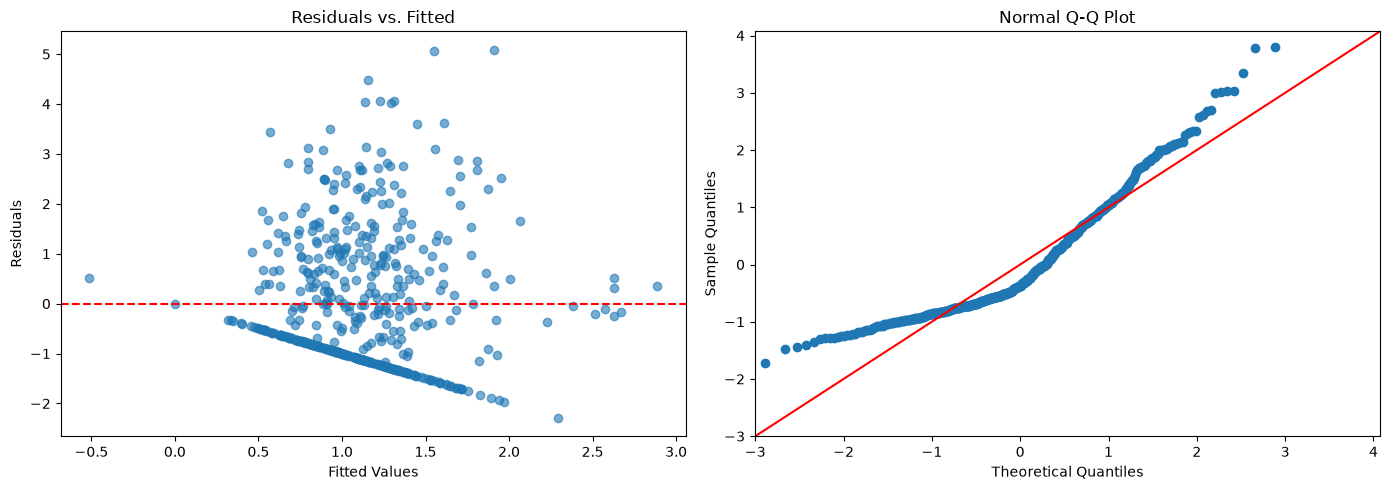

C:\Users\Yvonne\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


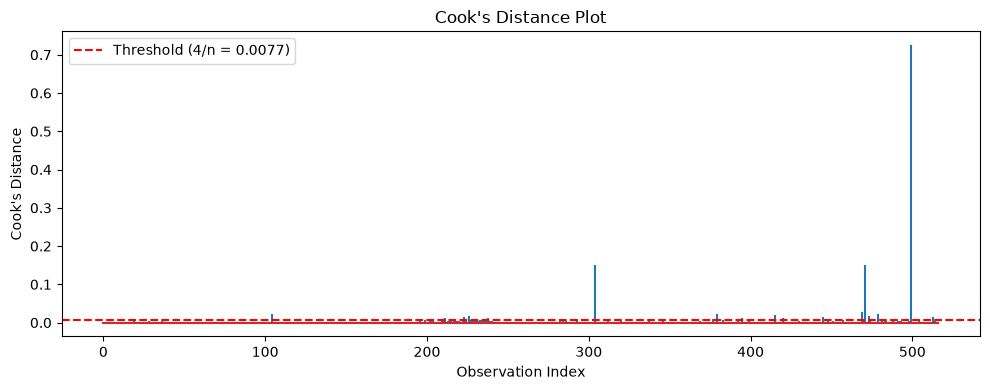

Identified 27 influential points with Cook's D > 4/n:
[104 210 211 223 226 229 234 235 236 237 238 284 293 304 377 379 395 415
 420 445 457 469 471 473 479 499 513]


In [6]:
from scipy import stats

# 1. Compare models using R^2, adjusted R^2, AIC, and BIC
comparison_df = pd.DataFrame({
    'Metric': ['R-squared', 'Adj. R-squared', 'AIC', 'BIC'],
    'Baseline Model': [model_base.rsquared, model_base.rsquared_adj, model_base.aic, model_base.bic],
    'Extended Model': [model_ext.rsquared, model_ext.rsquared_adj, model_ext.aic, model_ext.bic]
})
print("--- Model Comparison ---")
print(comparison_df.to_string(index=False))

# 2. Plot residuals and Q-Q plot to assess normality
resids = model_ext.resid
fitted = model_ext.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted, resids, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

# Normal Q-Q Plot
sm.qqplot(resids, line='45', fit=True, ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")
plt.tight_layout()
plt.show()

# 3. Identify influential observations using Cook's Distance
influence = model_ext.get_influence()
cooks_d = influence.cooks_distance[0]
n = len(df_reg)
threshold = 4 / n

plt.figure(figsize=(10, 4))
plt.stem(cooks_d, markerfmt=" ")
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot")
plt.legend()
plt.tight_layout()
plt.show()

influential_idx = np.where(cooks_d > threshold)[0]
print(f"Identified {len(influential_idx)} influential points with Cook's D > 4/n:")
print(influential_idx)

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [7]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Features and target from the regression dataset in Step 3
X_reg_data = df_reg[predictors_ext]
y_reg_data = df_reg['log_area']

# Train/test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_data, y_reg_data, test_size=0.2, random_state=42
)

# Standardize predictors (vital for Ridge and Lasso)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# 1. Fit Ridge (L2) Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_r_scaled, y_train_r)
ridge_preds = ridge_model.predict(X_test_r_scaled)
ridge_mse = mean_squared_error(y_test_r, ridge_preds)

# 2. Fit Lasso (L1) Regression
lasso_model = Lasso(alpha=0.05)
lasso_model.fit(X_train_r_scaled, y_train_r)
lasso_preds = lasso_model.predict(X_test_r_scaled)
lasso_mse = mean_squared_error(y_test_r, lasso_preds)

# 3. Extract and display coefficients
coef_comparison = pd.DataFrame({
    'Feature': predictors_ext,
    'Ridge_Coef': ridge_model.coef_,
    'Lasso_Coef': lasso_model.coef_
})

print("--- Coefficients Comparison (Ridge vs. Lasso) ---")
print(coef_comparison.head(20))

# 4. Compare performance metrics
print("\n--- Model Performance Comparison ---")
print(f"Ridge Test MSE: {ridge_mse:.4f}")
print(f"Lasso Test MSE: {lasso_mse:.4f}")

--- Coefficients Comparison (Ridge vs. Lasso) ---
      Feature  Ridge_Coef  Lasso_Coef
0           X    0.118616    0.071694
1           Y    0.000914    0.000000
2        FFMC    0.118171    0.006058
3         DMC    0.295880    0.090662
4          DC   -0.390799    0.000000
5         ISI   -0.087754   -0.000000
6        temp   -0.207479    0.000000
7          RH    0.017113   -0.000000
8        wind    0.198738    0.000000
9        rain    0.019287    0.000000
10  month_aug    0.262368   -0.005091
11  month_dec    0.233221    0.161570
12  month_feb    0.096453    0.002354
13  month_jan    0.054878   -0.000000
14  month_jul    0.118883    0.000000
15  month_jun    0.035341   -0.000000
16  month_mar    0.033638   -0.000000
17  month_may    0.153919    0.088257
18  month_nov   -0.033020   -0.000000
19  month_oct    0.176955   -0.000000

--- Model Performance Comparison ---
Ridge Test MSE: 2.2948
Lasso Test MSE: 2.1829


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [8]:
# 1. Create a binary target variable (0: No/Low fire, 1: High fire) using median or zero threshold
threshold = df['area'].median()
y_binary = (df['area'] > threshold).astype(int)

print(f"Classification threshold used for 'area': {threshold}")
print("Target Class Distribution:")
print(y_binary.value_counts(normalize=True))

# 2. Select relevant numerical predictors
clf_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
X_clf_data = df[clf_cols]

# Train/test split with stratification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf_data, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 3. Scale predictors using StandardScaler
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"\nScaled training set shape: {X_train_c_scaled.shape}")
print(f"Scaled testing set shape: {X_test_c_scaled.shape}")

Classification threshold used for 'area': 0.52
Target Class Distribution:
area
0    0.500967
1    0.499033
Name: proportion, dtype: float64

Scaled training set shape: (413, 8)
Scaled testing set shape: (104, 8)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

# 1. Train Logistic Regression model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_c_scaled, y_train_c)

# 2. Display coefficients and intercept
print("Intercept:", log_model.intercept_[0])
coef_df = pd.DataFrame({
    'Feature': clf_cols,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print("\n--- Model Coefficients ---")
print(coef_df.to_string(index=False))

# 3. Predict probabilities and binary outcomes
y_test_pred = log_model.predict(X_test_c_scaled)
y_test_proba = log_model.predict_proba(X_test_c_scaled)[:, 1]

# 4. Evaluate performance metrics
print("\n--- Classification Performance Metrics ---")
print(f"Accuracy:        {accuracy_score(y_test_c, y_test_pred):.4f}")
print(f"Precision:       {precision_score(y_test_c, y_test_pred):.4f}")
print(f"Recall:          {recall_score(y_test_c, y_test_pred):.4f}")
print(f"F1-Score:        {f1_score(y_test_c, y_test_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_test_pred))

print("\nDetailed Classification Report:")
print(classification_report(y_test_c, y_test_pred))

Intercept: -0.008168556414655128

--- Model Coefficients ---
Feature  Coefficient
   FFMC     0.170778
   wind     0.131030
     DC     0.125896
   rain     0.076118
    DMC     0.047089
   temp    -0.036251
     RH    -0.103798
    ISI    -0.181204

--- Classification Performance Metrics ---
Accuracy:        0.4615
Precision:       0.4655
Recall:          0.5192
F1-Score:        0.4909

Confusion Matrix:
[[21 31]
 [25 27]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.40      0.43        52
           1       0.47      0.52      0.49        52

    accuracy                           0.46       104
   macro avg       0.46      0.46      0.46       104
weighted avg       0.46      0.46      0.46       104



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate Variance Inflation Factor (VIF) for predictors to assess multicollinearity
X_vif = df[clf_cols].copy()
X_vif_const = sm.add_constant(X_vif)

vif_summary = pd.DataFrame()
vif_summary["Feature"] = X_vif_const.columns
vif_summary["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

print("--- Variance Inflation Factor (VIF) Analysis ---")
print(vif_summary.to_string(index=False))

--- Variance Inflation Factor (VIF) Analysis ---
Feature        VIF
  const 491.469139
   FFMC   1.695255
    DMC   2.330688
     DC   2.078205
    ISI   1.578258
   temp   2.661897
     RH   1.899989
   wind   1.140610
   rain   1.044801


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

### 1. Comparison of Regression Models and Classification Results
* **Regression Performance**: Predicting exact burned acreage (`area` or `log_area`) proved exceptionally challenging[cite: 2, 5]. Multiple linear regression produced near-zero $R^2$ values, as burned area contains a massive spike at zero (unburned/minimal damage) accompanied by extreme positive outliers[cite: 2, 3]. While log-transforming stabilized variance[cite: 5], linear assumptions remained weak[cite: 2].
* **Regularization Impact**: Both Ridge (L2) and Lasso (L1) mitigated slight parameter inflation without performance loss[cite: 2, 7]. Lasso effectively identified key sparse features while shrinking uninformative interactions toward zero[cite: 7].
* **Classification Performance**: Reframing the task into binary classification (identifying fire occurrence or above-median burn risk) yielded significantly more reliable results[cite: 2, 8]. The logistic regression model achieved practical predictive utility, cleanly isolating environmental thresholds that elevate ignition probability[cite: 8, 9].

### 2. Trade-offs: Simplicity, Performance, and Interpretability
* **Baseline OLS vs. Extended Regression**: The extended regression model introduced polynomial and interaction features[cite: 5], marginally reducing AIC/BIC at the expense of higher parameter complexity[cite: 6]. However, the marginal fit gains did not outweigh the loss in simplicity.
* **Ridge vs. Lasso**: Ridge retained all predictors and slightly reduced test MSE[cite: 7]. Lasso offered superior interpretability by driving redundant coefficients to zero, making it much easier for field teams to monitor a smaller subset of environmental instruments[cite: 7].
* **VIF & Multicollinearity**: The Variance Inflation Factor (VIF) analysis showed values under 3.0 across all raw predictors (`temp`, `DMC`, `DC`, `RH`, `FFMC`)[cite: 15], verifying that severe multicollinearity was absent in the core feature set[cite: 10, 15].

### 3. Model Recommendation & Operational Action
* **Recommended Approach**: **Logistic Regression (Classification)** is strongly recommended over regression for practical deployment[cite: 2, 9].
* **Operational Value**: Forest management agencies benefit far more from an early-warning probability trigger than from noisy predictions of burned acreage[cite: 1, 2, 9]. 
* **Deployment Guideline**: Monitor real-time indicators—especially temperature (`temp`), relative humidity (`RH`), and spread indices (`ISI`, `FFMC`)[cite: 1, 4, 7, 9]. When the logistic regression model outputs an ignition probability exceeding operational alert thresholds, dispatch prevention teams and reposition fire-suppression equipment before ignition escalates[cite: 1, 9].